### Intro to JAX
[JAX](https://github.com/google/jax) is a framework which is used for high-performance numerical computing and machine learning research developed at [Google Research](https://research.google/) teams. It allows you to build Python applications with a NumPy-consistent API that specializes in differentiating, vectorizing, parallelizing, and compiling to GPU/TPU Just-In-Time. JAX was designed with performance and speed as a first priority, and is natively compatible with common machine learning accelerators such as [GPUs](https://www.kaggle.com/docs/efficient-gpu-usage) and [TPUs](https://www.kaggle.com/docs/tpu). Large ML models can take ages to train -- you might be interested in using JAX for applications where speed and performance are particularly important!
### When to use JAX vs TensorFlow?
[TensorFlow](https://www.tensorflow.org/guide) is a fantastic product, with a rich and fully-featured ecosystem, capable of supporting most every use case a machine learning practitioner might have (e.g. [TFLite](https://www.tensorflow.org/lite) for on-device inference computing, [TFHub](https://tfhub.dev/) for sharing pre-trained models, and many additional specialized applications as well). This type of broad mandate both contrasts and compliments JAX's philosophy, which is more narrowly focused on speed and performance.  We recommend using JAX in situations where you do want to maximize speed and performance but you do not require any of the long tail of features and additional functionalities that only the [TensorFlow ecosystem](https://www.tensorflow.org/learn) can provide.
### Intro to the FLAX
Just like [JAX](https://jax.readthedocs.io/en/latest/notebooks/quickstart.html) focuses on speed, other members of the JAX ecosystem are encouraged to specialize as well.  For example, [Flax](https://flax.readthedocs.io/en/latest/) focuses on neural networks and [jgraph](https://github.com/deepmind/jraph) focuses on graph networks.  

[Flax](https://flax.readthedocs.io/en/latest/) is a JAX-based neural network library that was initially developed by  Google Research's Brain Team (in close collaboration with the JAX team) but is now open source.  If you want to train machine learning models on GPUs and TPUs at an accelerated speed, or if you have an ML project that might benefit from bringing together both [Autograd](https://github.com/hips/autograd) and [XLA](https://www.tensorflow.org/xla), consider using [Flax](https://flax.readthedocs.io/en/latest/) for your next project! [Flax](https://flax.readthedocs.io/en/latest/) is especially well-suited for projects that use large language models, and is a popular choice for cutting-edge [machine learning research](https://arxiv.org/search/?query=JAX&searchtype=all&abstracts=show&order=-announced_date_first&size=50).

## Imports

In [1]:
# Importing all the libraries necessary for the project
import jax
import flax
import numpy as np
import jax.numpy as jnp
import tensorflow as tf
import pandas as pd
import os
from flax import linen as nn # the Linen API
from flax.training import train_state 
import optax
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# List all the available devices
jax.local_devices()

[CpuDevice(id=0)]

## Load and Pre-process the dataset
In this notebook, we'll be using dataset from very famous Kaggle competition [Digit Recognizer](https://www.kaggle.com/c/digit-recognizer)

In [3]:
mnist_train = pd.read_csv('../input/digit-recognizer/train.csv')

In [4]:
labels = mnist_train["label"]
features = mnist_train.drop(labels = ["label"],axis = 1)
features = features/255.0
features = features.values.reshape(-1,28,28,1)
labels = labels.to_numpy()

In [5]:
labels.shape

(42000,)

In [6]:
features.shape

(42000, 28, 28, 1)

Creating a dictionary with images and labels


In [7]:
train_ds = {
        'images': features,
        'labels': labels
       }

## Define model architecture
We'll be using [FLAX Linen package](https://flax.readthedocs.io/en/latest/flax.linen.html) for defining the model architecture from scratch.

In [8]:
class CNN(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Conv(features=32, kernel_size=(3, 3))(x)
        x = nn.relu(x)
        x = nn.max_pool(x, window_shape=(2, 2), strides=(2, 2))
        x = nn.Conv(features=64, kernel_size=(3, 3))(x)
        x = nn.relu(x)
        x = nn.max_pool(x, window_shape=(2, 2), strides=(2, 2))
        x = x.reshape((x.shape[0], -1))
        x = nn.Dense(features=256)(x)
        x = nn.relu(x)
        x = nn.Dense(features=10)(x)   
        x = nn.log_softmax(x)
        return x

## Define loss and compute metrics
Now, we will define the functions which calculates the training loss and compute the metrics using the given predicted values and labels

In [9]:
def cross_entropy_loss(*, logits, labels):
    one_hot_labels = jax.nn.one_hot(labels, num_classes=10)
    return -jnp.mean(jnp.sum(one_hot_labels * logits, axis=-1))

def compute_metrics(logits, labels):
    loss = cross_entropy_loss(logits=logits, labels=labels)
    accuracy = jnp.mean(jnp.argmax(logits, -1) == labels)
    metrics = {
      'loss': loss,
      'accuracy': accuracy,
    }
    return metrics

## Defining train step
We will now define the function for training a single batch of data, which will take the current train state and the training data as input and return the updated train state along with the compute metrics.

In [10]:
@jax.jit
def train_step(state, batch):
    def loss_fn(params):
        logits = CNN().apply({'params': params}, batch['images'])
        loss = cross_entropy_loss(logits=logits, labels=batch['labels'])
        return loss, logits
    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
    (_, logits), grads = grad_fn(state.params)
    state = state.apply_gradients(grads=grads)
    metrics = compute_metrics(logits, batch['labels'])
    return state, metrics

In [11]:
per_device_batch_size = 32

total_batch_size = per_device_batch_size * jax.local_device_count()
print("The overall batch size (both for training and eval) is", total_batch_size)

The overall batch size (both for training and eval) is 32


## Train Function
We will now define the training function which takes the current train state, dataset, batch_size, and the rng as the input and returns the new train state along with the compute metrics

In [12]:
def train_epoch(state, train_ds, batch_size, epoch, rng):
    train_ds_size = len(train_ds['images'])
    steps_per_epoch = train_ds_size // batch_size 

    perms = jax.random.permutation(rng, train_ds_size)
    perms = perms[:steps_per_epoch * batch_size]  # skip incomplete batch
    perms = perms.reshape((steps_per_epoch, batch_size))
    batch_metrics = []
    for perm in perms:
        batch = {k: v[perm, ...] for k, v in train_ds.items()}
        state, metrics = train_step(state, batch)
        batch_metrics.append(metrics)

    training_batch_metrics = jax.device_get(batch_metrics)
    training_epoch_metrics = {
      k: np.mean([metrics[k] for metrics in training_batch_metrics])
      for k in training_batch_metrics[0]}

    print('Training - epoch: %d, loss: %.4f, accuracy: %.2f' % (epoch, training_epoch_metrics['loss'], training_epoch_metrics['accuracy'] * 100))

    return state, training_epoch_metrics

## Create train state
Creating the initial train state which we'll be passing to the neural network while training

In [13]:
def create_train_state(rng, learning_rate, momentum):
    cnn = CNN()
    params = cnn.init(rng, jnp.ones([1, 28,28,1]))['params']
    tx = optax.sgd(learning_rate, momentum)
    return train_state.TrainState.create(
      apply_fn=cnn.apply, params=params, tx=tx)

rng = jax.random.PRNGKey(0)
rng, init_rng = jax.random.split(rng)

learning_rate = 2e-5
momentum = 0.9
state = create_train_state(init_rng, learning_rate, momentum)
del init_rng

## Training
Next, we will train the neural network for 10 epochs andsee how well the model does.

In [14]:
num_epochs = 10
training_accuracy = []
for epoch in range(1, num_epochs + 1):
    rng, input_rng = jax.random.split(rng)
    state, train_metrics = train_epoch(state, train_ds, total_batch_size, epoch, input_rng)
    training_accuracy.append(train_metrics["accuracy"])

Training - epoch: 1, loss: 2.1689, accuracy: 38.05
Training - epoch: 2, loss: 1.8049, accuracy: 70.86
Training - epoch: 3, loss: 1.3564, accuracy: 77.75
Training - epoch: 4, loss: 0.9692, accuracy: 81.37
Training - epoch: 5, loss: 0.7351, accuracy: 83.82
Training - epoch: 6, loss: 0.6012, accuracy: 85.63
Training - epoch: 7, loss: 0.5184, accuracy: 87.02
Training - epoch: 8, loss: 0.4628, accuracy: 88.03
Training - epoch: 9, loss: 0.4231, accuracy: 88.83
Training - epoch: 10, loss: 0.3929, accuracy: 89.37


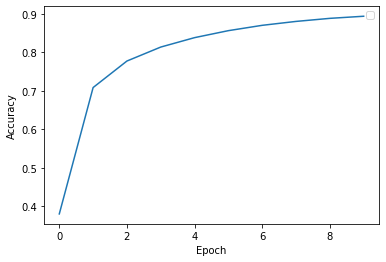

In [15]:
# Plot the Accuracy 
plt.plot(training_accuracy)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### **Conclusion**
Here in this notebook, we've illustrated how [JAX](https://github.com/google/jax) and [FLAX](https://flax.readthedocs.io/en/latest/) can be used to train the neural network for the toy image classification dataset, with the accuracy of more than 80%. To see more examples of how to use [JAX](https://github.com/google/jax) and [FLAX](https://flax.readthedocs.io/en/latest/) with different data formats, please see this discussion post.  

Now, it's your turn to  create some amazing notebooks using [JAX](https://github.com/google/jax) and [FLAX](https://flax.readthedocs.io/en/latest/). 

### **Useful resources which helped me:**
* https://flax.readthedocs.io/en/latest/notebooks/annotated_mnist.html
* https://jax.readthedocs.io/en/latest/